# Overview

## Spectra Analysis: Paint and Non-Paint Microplastic Classification
Welcome to the Spectra Analysis Jupyter Notebook, an interactive component of the research project accompanying the forthcoming paper: "A Paint Library Of Plastic Particles (PLOPP): Fourier Transform Infrared Spectral Analysis of Paint Microplastics" by Zoie T. Diana, Madeleine Milne, Jacob Ford, Ron Rubinovitz, Andrew Turner, and Chelsea M. Rochman.

This notebook supports the study's objective of developing a comprehensive FTIR-based paint library and enhancing environmental microplastic identification. By leveraging the Paint Library of Plastic Products (PLOPP), which houses spectra from various paint types, this project seeks to improve microplastic classification in environmental samples.

## Notebook Overview
The purpose of this notebook is to guide users through the ML pipeline developed to classify Fourier transform infrared (FTIR) spectra as either paint or non-paint microplastics, with an emphasis on:

- Data Preprocessing: Steps for preparing and transforming spectral data.
- Model Training and Selection: Implementation of a Gradient Boosting Classifier optimized for spectral data classification.
- Evaluation and Prediction: Assessing model accuracy and applying the classifier to real-world samples.

## Project Scope
The broader goal is to enable researchers and environmental scientists to use PLOPP for identifying paint microplastics among environmental samples, with initial tests focused on samples from the River Thames, United Kingdom. This notebook allows users to replicate our machine learning analysis and customize it for further exploration or validation.


In [1]:
# Import necessary libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_curve, auc)
from matplotlib.ticker import MaxNLocator
import shap

# Increase the decimal places in all columns 
pd.options.display.float_format = '{:.6f}'.format

# Optionally show all columns (commented out as it's not always necessary)
# pd.set_option('display.max_columns', None)


/Users/jacobford/Dropbox/Received from Jacob Ford - random forest modeling/PLOPP-analysis/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Load Data and Preprocess

## PLOPP

In [2]:
# Combine all the CSVs into one merged PLOPP dataset

def process_csv_files(directory):
    data_frames = []

    for filename in os.listdir(directory):
        if filename.lower().endswith('.csv'):  
            file_path = os.path.join(directory, filename) 

            df = pd.read_csv(file_path, header=None, names=['Wavelength', 'Datavalue'])
            df_transposed = df.set_index('Wavelength').T
            df_transposed['Sample'] = filename

            data_frames.append(df_transposed)

    master_df = pd.concat(data_frames, axis=0).fillna(0)

    return master_df

directory = "../../../../CSV Files/PLOPP/CSV Files"




plopp_df = process_csv_files(directory)

#plopp_df.columns = ['wavelength_' + str(col) if col not in ['Sample'] else col for col in plopp_df.columns]
plopp_df.columns = [int(col) if col not in ['Sample', 'Target', 'Wavelength'] else col for col in plopp_df.columns]


plopp_df['Target'] = "PLoPP"

# plopp_df.to_csv("../../../../CSV Files/PLOPP/plopp_merged.csv", index=False)



# Print the master DataFrame for review
print(plopp_df.shape)

plopp_df



(263, 938)


,397,401,404,408,412,416,420,424,428,431,...,3976,3980,3984,3988,3992,3995,3999,4003,Sample,Target
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.817920,91.799890,91.768400,91.759260,91.803400,91.885330,91.895230,0.000000,54c.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,97.245870,97.219830,97.283520,97.345570,97.343240,97.352390,97.383830,0.000000,23a.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.535050,91.539890,91.538020,91.560490,91.593530,91.580960,91.587860,0.000000,74a.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.119210,92.109000,92.050710,92.068950,92.132290,92.172480,92.242130,0.000000,78b.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.578730,94.567590,94.558040,94.586940,94.629390,94.671810,94.684270,0.000000,9a.CSV,PLoPP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,96.000130,96.019650,95.995780,95.956410,95.981160,96.036570,96.074420,0.000000,41b.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,100.101600,100.126900,100.160900,100.165200,100.168700,100.168900,100.157700,0.000000,82c.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.348060,91.368650,91.401120,91.413200,91.408660,91.441210,91.456630,0.000000,6c.CSV,PLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,93.008270,92.958400,92.905300,92.870000,92.903980,92.938250,92.967780,0.000000,16b.CSV,PLoPP


## FLOPP

In [3]:
directory = "../../../../CSV Files/FLOPP/8 cm -1 resolution CORRECT"

flopp_df = process_csv_files(directory)
#flopp_df.columns = ['wavelength_' + str(col) if col not in ['Sample'] else col for col in flopp_df.columns]
flopp_df.columns = [int(col) if col not in ['Sample'] else col for col in flopp_df.columns]


flopp_df['Target'] = "FLoPP"

#flopp_df.to_csv("../../CSV Files/FLOPP/Flopp_merged.csv", index=False)


print(flopp_df.shape)
# Print the master DataFrame for review
flopp_df


(186, 938)


,397,401,404,408,412,416,420,424,428,431,...,3976,3980,3984,3988,3992,3995,3999,4003,Sample,Target
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.040790,98.064640,98.072340,98.090140,98.065730,98.030320,98.040350,0.000000,PE 12_8cm.CSV,FLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.498280,98.516020,98.449390,98.543720,98.516090,98.505090,98.499170,0.000000,ABS12_8cm.CSV,FLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,104.306700,104.303800,104.309200,104.332100,104.467600,104.351000,104.341500,0.000000,Nylon 5_8cm.CSV,FLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101.102700,101.123400,101.041400,101.108400,101.113200,101.091900,101.109900,0.000000,PET 2_8cm.CSV,FLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.888720,99.043970,98.959140,98.883790,98.834790,99.027960,99.004300,0.000000,Acrylic5_8cm.CSV,FLoPP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,99.188320,99.233940,99.190930,99.225070,99.156200,99.293390,99.180210,0.000000,PEVA 10_8cm.CSV,FLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,97.601630,97.646840,97.662280,97.705030,97.718460,97.702880,97.682560,0.000000,Polyester 10_8cm.CSV,FLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,99.619910,99.624230,99.595730,99.585510,99.593260,99.630400,99.604730,0.000000,PLA 9_8cm.CSV,FLoPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,99.648720,99.642620,99.626400,99.630580,99.635880,99.643420,99.582090,0.000000,PU 6_8 cm.CSV,FLoPP


## Merging


In [4]:
flopps_cols = flopp_df.columns
plopp_cols = plopp_df.columns

# print out the column elements

merged_cols = [i for i in plopp_cols if i in flopps_cols]

In [5]:
import re

result_df = pd.concat([flopp_df, plopp_df], axis=0, ignore_index=True)

def extract_integer_prefix(sample_name):
    match = re.match(r'^(\d+)', sample_name)
    return match.group(1) if match else None

# Apply the function to create a 'Group' column
result_df['Group'] = result_df['Sample'].apply(extract_integer_prefix)

result_df

,397,401,404,408,412,416,420,424,428,431,...,3980,3984,3988,3992,3995,3999,4003,Sample,Target,Group
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.064640,98.072340,98.090140,98.065730,98.030320,98.040350,0.000000,PE 12_8cm.CSV,FLoPP,None
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.516020,98.449390,98.543720,98.516090,98.505090,98.499170,0.000000,ABS12_8cm.CSV,FLoPP,None
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,104.303800,104.309200,104.332100,104.467600,104.351000,104.341500,0.000000,Nylon 5_8cm.CSV,FLoPP,None
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101.123400,101.041400,101.108400,101.113200,101.091900,101.109900,0.000000,PET 2_8cm.CSV,FLoPP,None
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,99.043970,98.959140,98.883790,98.834790,99.027960,99.004300,0.000000,Acrylic5_8cm.CSV,FLoPP,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,96.019650,95.995780,95.956410,95.981160,96.036570,96.074420,0.000000,41b.CSV,PLoPP,41
445,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,100.126900,100.160900,100.165200,100.168700,100.168900,100.157700,0.000000,82c.CSV,PLoPP,82
446,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.368650,91.401120,91.413200,91.408660,91.441210,91.456630,0.000000,6c.CSV,PLoPP,6
447,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.958400,92.905300,92.870000,92.903980,92.938250,92.967780,0.000000,16b.CSV,PLoPP,16


In [7]:
result_df.shape

(449, 939)

In [27]:
# result_df.to_csv("../../data/output/merged_df.csv")

In [8]:
# Separate the data into PLOPP and FLOPP based on the 'Group' column
plopp_df = result_df[result_df['Target'] != 'FLoPP']
flopp_df = result_df[result_df['Target'] == 'FLoPP']

# Step 1: Group by 'Group' and split the PLOPP data
plopp_train_groups, plopp_test_groups = train_test_split(plopp_df['Group'].unique(), test_size=0.4, random_state=42)

plopp_train_df = plopp_df[plopp_df['Group'].isin(plopp_train_groups)]
plopp_test_df = plopp_df[plopp_df['Group'].isin(plopp_test_groups)]

# Step 2: Perform regular train-test split for FLOPP
flopp_train_df, flopp_test_df = train_test_split(flopp_df, test_size=0.4, random_state=42)

# Step 3: Combine the train and test datasets
train_df = pd.concat([plopp_train_df, flopp_train_df])
test_df = pd.concat([plopp_test_df, flopp_test_df])

X_train = train_df.drop(['Target', 'Sample', 'Group'], axis=1)
y_train = train_df['Target']

X_test = test_df.drop(['Target', 'Sample', 'Group'], axis=1)
y_test = test_df['Target']


In [9]:
X_train

,397,401,404,408,412,416,420,424,428,431,...,3968,3972,3976,3980,3984,3988,3992,3995,3999,4003
187,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,97.263050,97.283120,97.245870,97.219830,97.283520,97.345570,97.343240,97.352390,97.383830,0.000000
188,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.585410,91.571660,91.535050,91.539890,91.538020,91.560490,91.593530,91.580960,91.587860,0.000000
189,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.167590,92.163630,92.119210,92.109000,92.050710,92.068950,92.132290,92.172480,92.242130,0.000000
192,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.770170,98.860340,98.881480,98.836830,98.852810,98.843320,98.820400,98.824940,98.892400,0.000000
193,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.634390,92.650370,92.630660,92.619170,92.661870,92.692000,92.689920,92.728150,92.777500,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101.874500,101.892200,101.792500,101.840100,101.746900,101.833600,101.808000,101.785900,101.809400,0.000000
14,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,99.493710,99.505710,99.425090,99.474850,99.364290,99.450770,99.435880,99.398120,99.414190,0.000000
92,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.543770,98.505360,98.500600,98.482160,98.479150,98.453250,98.490100,98.447620,98.501180,0.000000
179,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.661340,98.704450,98.651250,98.657890,98.621650,98.666670,98.609160,98.638690,98.637960,0.000000


# Hyperparameter Tuning

In [10]:

def standard_normal_variate(X):
    mean_centered = X - np.mean(X, axis=1, keepdims=True)
    snv_transformed = mean_centered / np.std(mean_centered, axis=1, keepdims=True)
    return snv_transformed

def calculate_derivatives(data, window_length, polyorder, deriv=1):
    return savgol_filter(data, window_length, polyorder, deriv=deriv)

class SNVTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, use_scaling=True):
        self.use_scaling = use_scaling

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = np.array(X)
        mean_centered = X - np.mean(X, axis=1, keepdims=True)
        if self.use_scaling:
            return mean_centered / np.std(mean_centered, axis=1, keepdims=True)
        return mean_centered

class DerivativeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, window_length=11, polyorder=2, deriv=1):
        self.window_length = window_length
        self.polyorder = polyorder
        self.deriv = deriv
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = np.array(X)
        transformed = np.apply_along_axis(calculate_derivatives, axis=1, arr=X,
                                          window_length=self.window_length, 
                                          polyorder=self.polyorder, deriv=self.deriv)
        return transformed


In [31]:


# result_df['Target'] = result_df['Target'].map({'FLOPP': 0, 'PLOPP': 1})
# features = result_df.drop(['Target', 'Sample'], axis=1)
# target = result_df['Target']

# X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.4, random_state=42)

# print('Training data shape:', X_train.shape)
# print('Testing data shape:', X_test.shape)

# # Models to be evaluated
# models = {
#     'Random Forest': RandomForestClassifier(),
#     'Logistic Regression': LogisticRegression(max_iter=1000),
#     'SVM': SVC(probability=True),
#     'XGBoost': XGBClassifier()
# }

# best_model_name = None
# best_f1_score = 0
# best_params = {}

# for name, model in models.items():
#     pipeline = Pipeline([
#         ('snv', SNVTransformer()),
#         ('derivatives', DerivativeTransformer()),
#         ('classifier', model)
#     ])
    
#     param_grid = {
#         'snv__use_scaling': [True, False],
#         'derivatives__deriv': [0, 1, 2]
#     }

#     if name == 'XGBoost':
#         param_grid.update({
#             'classifier__n_estimators': [100, 500],
#             'classifier__learning_rate': [0.01, 0.05, 0.1],
#             'classifier__max_depth': [3, 6, 9]
#         })

#     if name == "Random Forest":
#         param_grid.update({
#             'classifier__n_estimators': [100, 200, 300, 500],
#             'classifier__max_depth': [3, 6, 9],
#             'classifier__min_samples_split': [2, 5, 10],
#             'classifier__min_samples_leaf': [1, 2, 4],
#             'classifier__max_features': ['auto', 'sqrt', 'log2']
#         })

#     if name == "Logistic Regression":
#         param_grid.update({
#             'classifier__penalty': ['l1', 'l2', 'elasticnet', 'none'],
#             'classifier__C': [0.01, 0.1, 1, 10, 100],
#             'classifier__solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
#         })

#     if name == "SVM":
#         param_grid.update({
#             'classifier__C': [0.1, 1, 10, 100],
#             'classifier__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
#             'classifier__gamma': ['scale', 'auto']
#         })

#     grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', verbose=1)
    
#     grid_search.fit(X_train, y_train)
    
#     print(f"Best parameters for {name}:", grid_search.best_params_)
#     print(f"Best cross-validation score (F1) for {name}: {grid_search.best_score_:.3f}")
    
#     if grid_search.best_score_ > best_f1_score:
#         best_f1_score = grid_search.best_score_
#         best_model_name = name
#         best_params = grid_search.best_params_

# with open('best_params.json', 'w') as f:
#     json.dump(best_params, f)

# print(f"The best model is {best_model_name} with a cross-validation F1 score of {best_f1_score:.3f}")


In [11]:
best_params = {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'derivatives__deriv': 1, 'snv__use_scaling': True}

best_params

{'classifier__learning_rate': 0.1,
 'classifier__max_depth': 3,
 'classifier__n_estimators': 100,
 'derivatives__deriv': 1,
 'snv__use_scaling': True}

# Model Training and Evaluation

In [12]:
X_test.head()

,397,401,404,408,412,416,420,424,428,431,...,3968,3972,3976,3980,3984,3988,3992,3995,3999,4003
186,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.838240,91.834510,91.817920,91.799890,91.768400,91.759260,91.803400,91.885330,91.895230,0.000000
190,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.523770,94.543520,94.578730,94.567590,94.558040,94.586940,94.629390,94.671810,94.684270,0.000000
191,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,99.696180,99.703460,99.700480,99.662410,99.625500,99.601970,99.618930,99.689800,99.727460,0.000000
195,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,93.734760,93.704450,93.692960,93.727500,93.765440,93.746410,93.698810,93.729640,93.786670,0.000000
196,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,97.235770,97.106380,97.051010,97.110660,97.192470,97.254630,97.234380,97.171360,97.113910,0.000000


## Pipeline

In [13]:
# Create the pipeline with PCA included
pipeline = Pipeline([
    ('snv', SNVTransformer(use_scaling=True)),                # Apply SNV transformation
    ('derivative', DerivativeTransformer(deriv=1)),           # Apply derivative transformation
    ('pca', PCA(n_components=0.95)),                          # Apply PCA to retain 95% variance
    ('classifier', RandomForestClassifier(random_state=42))   # A RandomForest model
])

# Drop 'Group' from X_train before fitting the pipeline
pipeline.fit(X_train, y_train)

# Extract the PCA step from the pipeline
pca = pipeline.named_steps['pca']

# Calculate the cumulative variance explained by the components
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Find the number of components that explain at least 95% of the variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Number of components that account for 95% of the variance: {n_components_95}")
print("Cumulative variance explained by each component:")

# Print the cumulative variance and top contributing features for each component
for i, cumulative_var in enumerate(cumulative_variance):
    if i < n_components_95:  # Only print for components up to 95% variance
        print(f"\nComponent {i+1} (Cumulative Variance: {cumulative_var:.4f}):")
        # Get the top contributing features for this component
        component = pca.components_[i]
        feature_importance = pd.Series(component, index=X_train.columns)
        top_features = feature_importance.abs().sort_values(ascending=False).head(10)
        for feature, importance in top_features.items():
            print(f"  Feature: {feature}, Importance: {importance:.4f}")

# Drop 'Group' from X_test before making predictions
#X_test = X_test.drop(columns=['Group'])

# Predict probabilities for each class
y_pred_proba = pipeline.predict_proba(X_test)

#y_pred =

# Apply a cutoff of 0.60 for the positive class ('PLoPP')
y_pred = np.where(y_pred_proba[:, 1] >= 0.60, 'PLoPP', 'FLoPP')

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='PLoPP')
recall = recall_score(y_test, y_pred, pos_label='PLoPP')
f1 = f1_score(y_test, y_pred, pos_label='PLoPP')

# Print evaluation metrics
print(f"\nRandom Forest Model Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Number of components that account for 95% of the variance: 16
Cumulative variance explained by each component:

Component 1 (Cumulative Variance: 0.3250):
  Feature: 1735, Importance: 0.1841
  Feature: 1739, Importance: 0.1833
  Feature: 1743, Importance: 0.1714
  Feature: 740, Importance: 0.1705
  Feature: 1731, Importance: 0.1640
  Feature: 1700, Importance: 0.1590
  Feature: 736, Importance: 0.1581
  Feature: 1704, Importance: 0.1577
  Feature: 1747, Importance: 0.1515
  Feature: 1226, Importance: 0.1513

Component 2 (Cumulative Variance: 0.4910):
  Feature: 1747, Importance: 0.2290
  Feature: 1751, Importance: 0.2238
  Feature: 1743, Importance: 0.2037
  Feature: 1754, Importance: 0.1943
  Feature: 1720, Importance: 0.1780
  Feature: 1716, Importance: 0.1761
  Feature: 674, Importance: 0.1701
  Feature: 671, Importance: 0.1695
  Feature: 667, Importance: 0.1590
  Feature: 678, Importance: 0.1582

Component 3 (Cumulative Variance: 0.5656):
  Feature: 1735, Importance: 0.1719
  Featu

Total number of false positives: 4
Total number of false negatives: 5
Total Accuracy: 0.95
True Positive Rate: 0.95
False Positive Rate: 0.05
True Negative Rate: 0.95
False Negative Rate: 0.05


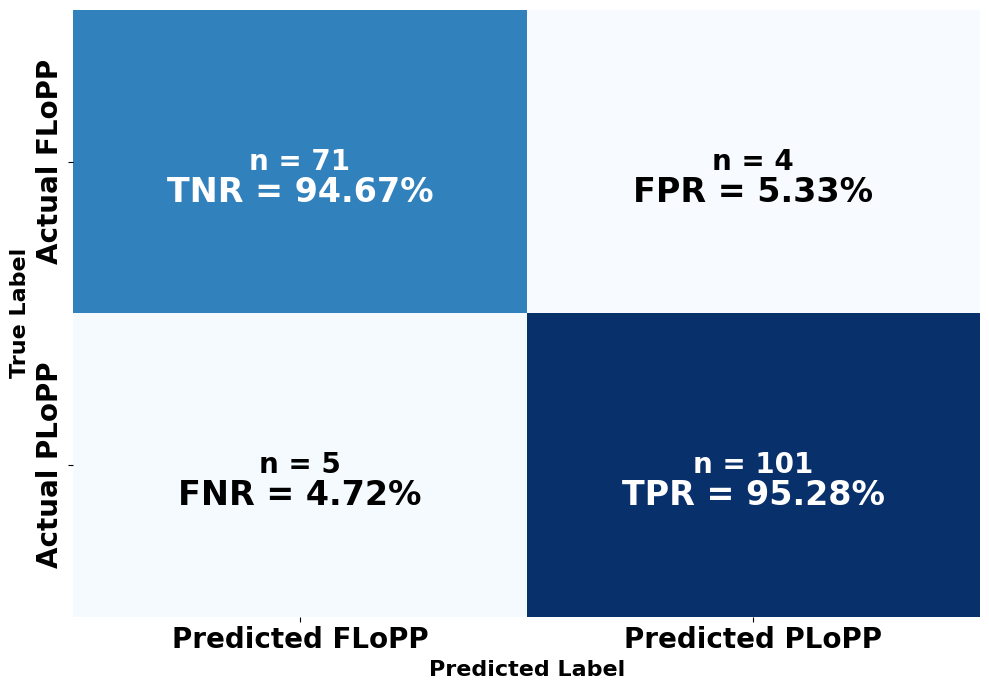

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Calculate additional metrics
total_accuracy = (tp + tn) / (tp + tn + fp + fn)
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)
tnr = tn / (tn + fp)
fnr = fn / (fn + tp)

print(f'Total number of false positives: {fp}')
print(f'Total number of false negatives: {fn}')


print(f'Total Accuracy: {total_accuracy:.2f}')
print(f'True Positive Rate: {tpr:.2f}')
print(f'False Positive Rate: {fpr:.2f}')
print(f'True Negative Rate: {tnr:.2f}')
print(f'False Negative Rate: {fnr:.2f}')

# Creating a DataFrame for Confusion Matrix for better visualization
confusion_df = pd.DataFrame(cm, index=['Actual FLoPP', 'Actual PLoPP'], columns=['Predicted FLoPP', 'Predicted PLoPP'])

# Plotting the confusion matrix heatmap
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(confusion_df, annot=False, fmt='d', cmap='Blues', cbar=False, ax=ax)  # Set annot=True to show numbers
#ax.set_title('Random Forest Confusion Matrix')
ax.set_xlabel('Predicted Label', fontsize=16, weight='bold')
ax.set_ylabel('True Label', fontsize=16, weight='bold')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=20, weight='bold')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=20, weight='bold')

# Annotate confusion matrix with TPR, FPR, etc.
for i in range(2):
    for j in range(2):
        color = 'white' if (i == 0 and j == 0) or (i == 1 and j == 1) else 'black'
        plt.text(j + 0.5, i + 0.5, f'n = {cm[i, j]}', ha='center', va='center', color=color, fontsize=20, weight='bold')

plt.text(0.5, 0.6, f'TNR = {tnr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold', color='white')
plt.text(1.5, 0.6, f'FPR = {fpr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold')
plt.text(.5, 1.6, f'FNR = {fnr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold')
plt.text(1.5, 1.6, f'TPR = {tpr * 100:.2f}%', ha='center', va='center', fontsize=24, weight='bold', color='white')
plt.tight_layout()
#save this plot to a folder:
# plt.savefig('../../../../Manuscript/Figures/Figure 4 Confusion matrix and box and whisker/Figure4_confusion_matrix.png')

plt.show()

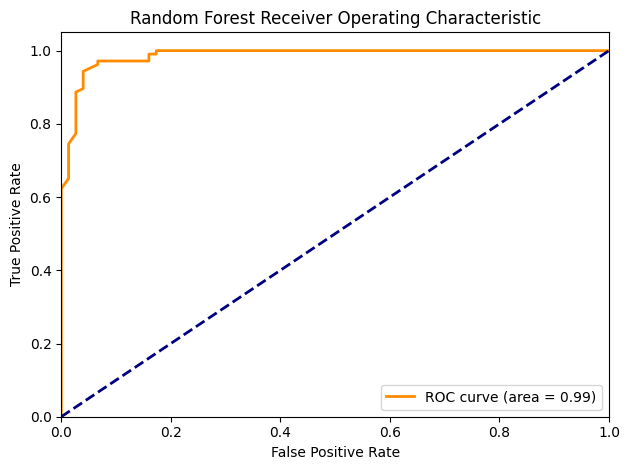

In [ ]:
# ROC Curve
y_prob = pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label='PLoPP')
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots()
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:0.2f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Random Forest Receiver Operating Characteristic')
ax.legend(loc="lower right")
plt.tight_layout()
#plt.savefig('../../../../Manuscript/Figures/Figure 4 Confusion matrix and box and whisker/Figure_ROC_curve.png')

plt.show()

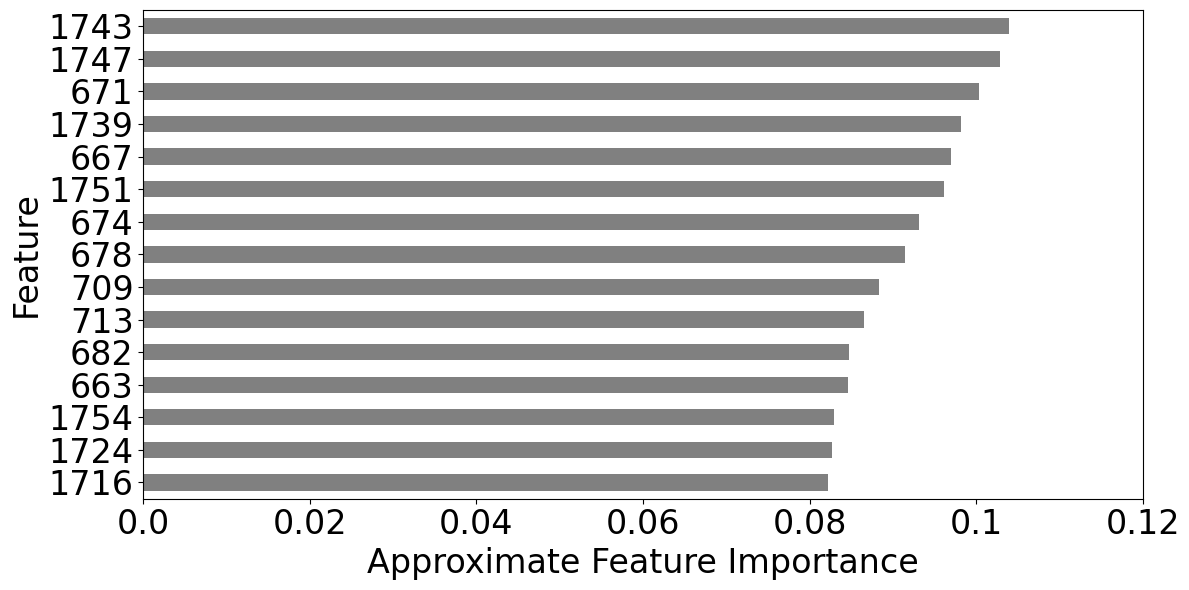

In [ ]:
# Access the PCA and classifier from the pipeline
pca = pipeline.named_steps['pca']
classifier = pipeline.named_steps['classifier']

# Get the importance of the components from the classifier
component_importances = classifier.feature_importances_

# Get the original feature names and the PCA components
original_feature_names = X_train.columns
pca_components = pca.components_

# Calculate the approximate importance of the original features
approx_feature_importances = np.zeros(len(original_feature_names))

for i, component_importance in enumerate(component_importances):
    approx_feature_importances += component_importance * np.abs(pca_components[i])

# Create a series with the approximate importances
approx_importances_series = pd.Series(approx_feature_importances, index=original_feature_names)

# Sort and get the top 15 most important features
top_importances = approx_importances_series.sort_values(ascending=True)[-15:]

# Plot the feature importances
fig, ax = plt.subplots(figsize=(12, 6))
top_importances.plot(kind='barh', ax=ax, color='grey')

# Customize the plot with larger font sizes
ax.set_ylabel("Feature", fontsize=24)
ax.set_xlabel("Approximate Feature Importance", fontsize=24)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticks(), fontsize=24)
ax.set_yticklabels(top_importances.index, fontsize=24)
plt.tight_layout()
#plt.savefig('../../../../Manuscript/Figures/Figure 4 Confusion matrix and box and whisker/Figure_Estimated_Feature_Importance.png')


plt.show()


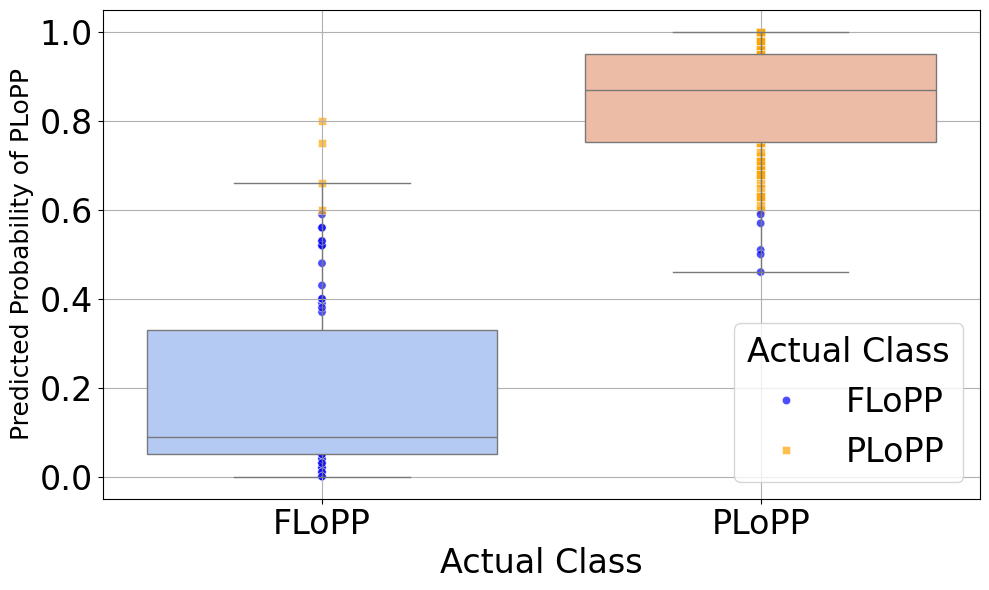

In [16]:
# Predicted Probabilities Plot
plot_data = pd.DataFrame({
    'Predicted Probability': y_prob,
    'Predicted Class': y_pred,
    'Actual Class': y_test
})

# Convert 'Actual Class' to a categorical type and rename categories
plot_data['Actual Class'] = pd.Categorical(plot_data['Actual Class'])
plot_data['Actual Class'] = plot_data['Actual Class'].cat.rename_categories({0: 'FLoPP', 1: 'PLoPP'})
plot_data['Predicted Class'] = pd.Categorical(plot_data['Predicted Class'])
plot_data['Predicted Class'] = plot_data['Predicted Class'].cat.rename_categories({0: 'FLoPP', 1: 'PLoPP'})

plt.figure(figsize=(10, 6))

# Create a scatter plot with custom colors for Predicted Class
sns.scatterplot(
    data=plot_data, 
    y='Predicted Probability', 
    x='Actual Class',  
    hue='Predicted Class',  # Color by Predicted Class
    style='Predicted Class', 
    palette={'FLoPP': 'blue', 'PLoPP': 'orange'},  # Custom palette
    markers=['o', 's'], 
    alpha=0.7
)

# Create a horizontal boxplot overlay
sns.boxplot(
    data=plot_data, 
    y='Predicted Probability', 
    x='Actual Class', 
    hue='Actual Class', 
    palette='coolwarm',  # Original color palette for Actual Class
    whis=1.5, 
    fliersize=0
)

# Customize the plot with larger font sizes
plt.ylabel('Predicted Probability of PLoPP', fontsize=18)
plt.xlabel('Actual Class', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.grid(True)

# Adjust legend to show both hue and style with larger font size
plt.legend(title='Actual Class', loc='lower right', fontsize=24, title_fontsize=24)

# Adjust layout to prevent clipping
plt.tight_layout()  # Ensures everything fits without being cut off

# Save the plot
#plt.savefig('../../../../Manuscript/Figures/Figure 4 Confusion matrix and box and whisker/Figure_box_and_whiskers.png')

plt.show()


In [17]:
print("Overall Model Stats")

# Max, Min, and Mean values of the predicted probabilities, rounded to 2 decimal places
print(f"Max Predicted Probability: {plot_data['Predicted Probability'].max():.2f}")
print(f"Min Predicted Probability: {plot_data['Predicted Probability'].min():.2f}")
print(f"Mean Predicted Probability: {plot_data['Predicted Probability'].mean():.2f}")

print("----------")
print("PLoPP Stats")

# Stats for when Predicted Class = 'PLoPP', rounded to 2 decimal places
print(f"Max Predicted Probability: {plot_data[plot_data['Predicted Class'] == 'PLoPP']['Predicted Probability'].max():.2f}")
print(f"Min Predicted Probability: {plot_data[plot_data['Predicted Class'] == 'PLoPP']['Predicted Probability'].min():.2f}")
print(f"Mean Predicted Probability: {plot_data[plot_data['Predicted Class'] == 'PLoPP']['Predicted Probability'].mean():.2f}")

print("----------")
print("FLoPP Stats")

# Stats for when Predicted Class = 'FLoPP', rounded to 2 decimal places
print(f"Max Predicted Probability: {plot_data[plot_data['Predicted Class'] == 'FLoPP']['Predicted Probability'].max():.2f}")
print(f"Min Predicted Probability: {plot_data[plot_data['Predicted Class'] == 'FLoPP']['Predicted Probability'].min():.2f}")
print(f"Mean Predicted Probability: {plot_data[plot_data['Predicted Class'] == 'FLoPP']['Predicted Probability'].mean():.2f}")


Overall Model Stats
Max Predicted Probability: 1.00
Min Predicted Probability: 0.00
Mean Predicted Probability: 0.57
----------
PLoPP Stats
Max Predicted Probability: 1.00
Min Predicted Probability: 0.60
Mean Predicted Probability: 0.85
----------
FLoPP Stats
Max Predicted Probability: 0.59
Min Predicted Probability: 0.00
Mean Predicted Probability: 0.19


# Andrew Turner's Samples

In [18]:
# load data

def process_csv_files(directory):
    data_frames = []

    for filename in os.listdir(directory):
        # add logic if filename has 'samplekey' in title, skip
        if filename != 'SampleKey.csv' and filename != 'merged' and filename.endswith('.CSV'):
            file_path = os.path.join(directory, filename) 

            df = pd.read_csv(file_path, header=None, names=['Wavelength', 'Datavalue'])
            df_transposed = df.set_index('Wavelength').T
            df_transposed['Sample'] = filename

            data_frames.append(df_transposed)

    master_df = pd.concat(data_frames, axis=0).fillna(0)

    return master_df


directory = "../../Andrew Turner data"


validate_df = process_csv_files(directory)

# remove .csv from Sample column
validate_df['Sample'] = validate_df['Sample'].str.replace('.CSV', '')

sample_key = pd.read_csv("../../Andrew Turner data/SampleKey.csv")

validate_df.head()

Wavelength,397.280900,401.138000,404.995100,408.852200,412.709300,416.566400,420.423500,424.280500,428.137700,431.994800,...,3972.809000,3976.666000,3980.523000,3984.380000,3988.237000,3992.094000,3995.951000,3999.809000,4003.666000,Sample
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101.121800,101.152700,101.197500,101.186000,101.151200,101.145900,101.174800,101.189200,0.000000,MP_ID_23
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101.332600,101.315000,101.274100,101.285100,101.336300,101.368500,101.389200,101.468100,0.000000,MP_ID_37
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,109.341000,109.454800,109.488300,109.513500,109.455400,109.437100,109.406500,109.319500,0.000000,MP_ID_36
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,102.429800,102.423600,102.490100,102.525900,102.514200,102.469900,102.457500,102.534400,0.000000,MP_ID_22
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,117.659600,117.683100,117.735100,117.775200,117.746500,117.706100,117.766300,117.842800,0.000000,MP_ID_34


In [19]:
merged_df = pd.merge(validate_df, sample_key, left_on='Sample', right_on = "Mira's ID", how='left')

merged_df.columns = [int(col) if col not in ['Sample', "Mira's ID", 'Paint or non-paint'] else col for col in merged_df.columns]

# rename 'Paint or non-Paint' to 'observed'
merged_df.rename(columns={"Paint or non-paint": "observed"}, inplace=True)
merged_df.drop(["Mira's ID"], axis=1, inplace=True) 

merged_df['observed'] = merged_df['observed'].map({'Non-paint': 'FLOPP', 'Paint': 'PLOPP'})

#merged_df.to_csv('../../Andrew Turner data/merged_validation_data.csv')

# change the name of observed to PLoPP if PLOPP and FLoPP if FLOPP
merged_df['observed'] = merged_df['observed'].map({'PLOPP': 'PLoPP', 'FLOPP': 'FLoPP'})

merged_df


,397,401,404,408,412,416,420,424,428,431,...,3976,3980,3984,3988,3992,3995,3999,4003,Sample,observed
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101.152700,101.197500,101.186000,101.151200,101.145900,101.174800,101.189200,0.000000,MP_ID_23,PLoPP
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101.315000,101.274100,101.285100,101.336300,101.368500,101.389200,101.468100,0.000000,MP_ID_37,PLoPP
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,109.454800,109.488300,109.513500,109.455400,109.437100,109.406500,109.319500,0.000000,MP_ID_36,PLoPP
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,102.423600,102.490100,102.525900,102.514200,102.469900,102.457500,102.534400,0.000000,MP_ID_22,PLoPP
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,117.683100,117.735100,117.775200,117.746500,117.706100,117.766300,117.842800,0.000000,MP_ID_34,PLoPP
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,75.696340,75.881630,75.487300,75.682500,76.190480,76.269230,76.075730,0.000000,MP_ID_20,PLoPP
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,104.543900,104.591000,104.622400,104.597900,104.599300,104.563800,104.549500,0.000000,MP_ID_21,PLoPP
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,103.706300,103.690000,103.680700,103.639800,103.622700,103.614000,103.615000,0.000000,MP_ID_35,PLoPP
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,107.156400,107.264300,107.457800,107.380900,107.168600,107.099400,107.019600,0.000000,MP_ID_31,PLoPP
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.809420,98.874020,98.885690,98.853420,98.825720,98.865810,98.916160,0.000000,MP_ID_25,PLoPP


In [20]:
merged_df.observed.value_counts()

observed
PLoPP    32
FLoPP     7
Name: count, dtype: int64

In [21]:
# Ensure 'Group' is not part of the input data if it exists
if 'Group' in merged_df.columns:
    X_validation = merged_df.drop(columns=['Group'])
else:
    X_validation = merged_df

# Use the pipeline to make predictions on the external validation data
X_validation_features = X_validation.drop(columns=['Sample', 'observed'])
y_validation_pred = pipeline.predict(X_validation_features)

# If you want probabilities instead of just predictions
y_validation_proba = pipeline.predict_proba(X_validation_features)

# Optional: Evaluate the predictions if you have the true labels in `merged_df`
if 'observed' in merged_df.columns:
    y_validation_true = merged_df['observed']

    accuracy = accuracy_score(y_validation_true, y_validation_pred)
    precision = precision_score(y_validation_true, y_validation_pred, average='weighted')
    recall = recall_score(y_validation_true, y_validation_pred, average='weighted')
    f1 = f1_score(y_validation_true, y_validation_pred, average='weighted')

    print(f"Validation Data Evaluation:")
    print("Accuracy:", accuracy)
    print("Precision (weighted):", precision)
    print("Recall (weighted):", recall)
    print("F1 Score (weighted):", f1)

    # print the false positive rate and true positive rate
    cm = confusion_matrix(y_validation_true, y_validation_pred)
    tn, fp, fn, tp = cm.ravel()

    # Calculate additional metrics
    total_accuracy = (tp + tn) / (tp + tn + fp + fn)
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    tnr = tn / (tn + fp)
    fnr = fn / (fn + tp)

    print(f'Total Accuracy: {total_accuracy:.2f}')
    print(f'True Positive Rate: {tpr:.2f}')
    print(f'False Positive Rate: {fpr:.2f}')
    print(f'True Negative Rate: {tnr:.2f}')
    print(f'False Negative Rate: {fnr:.2f}')
    


Validation Data Evaluation:
Accuracy: 0.8461538461538461
Precision (weighted): 0.8891108891108891
Recall (weighted): 0.8461538461538461
F1 Score (weighted): 0.8581196581196582
Total Accuracy: 0.85
True Positive Rate: 0.84
False Positive Rate: 0.14
True Negative Rate: 0.86
False Negative Rate: 0.16


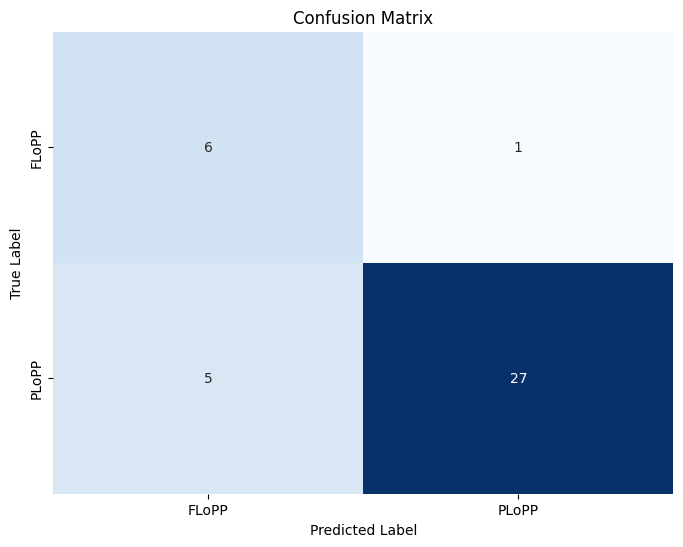

In [22]:
cm = confusion_matrix(y_validation_true, y_validation_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=pipeline.classes_, yticklabels=pipeline.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#  Paint by sector